# 3. Why alarms can fail to identify failures
A process excursion and a recorded failure are different events. Monitoring variables are now selected within the early reference window. Historically labelled pass runs approximate normal operation, but do not establish an in-control process.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / 'src'))
OUT = ROOT / 'reports/study'
summary = json.loads((OUT / 'summary.json').read_text())
def table(name): return pd.read_csv(OUT / f'{name}.csv')


In [2]:
display(table('control_limits'))
display(table('monitor_methods'))
display(table('alarm_union_diagnostics'))

,feature,mean,scale,i_limit_z,mr_limit_z
0,sensor_459,2.872154,0.811226,2.540926,3.120753
1,sensor_455,3.844148,1.018716,2.251072,2.764757
2,sensor_319,8.365631,2.283124,2.193342,2.693853
3,sensor_187,18.151433,5.117326,2.548144,3.129619
4,sensor_183,28.175981,7.499233,2.257365,2.772485
5,sensor_564,6.119678,2.233767,2.478234,3.043756
6,sensor_568,2.352627,0.867949,2.470441,3.034185
7,sensor_323,5.445081,1.498758,2.568867,3.155071
8,sensor_566,2.492121,0.912054,2.429798,2.984267
9,sensor_550,17.573626,5.330507,1.770778,2.174862


,method,alert_rate,failure_recall,failure_capture,precision,false_positive_rate,alerts_per_100_runs,failure_capture_lift_over_random,pass_runs_between_false_alerts,alerts,failures_captured,false_alerts
0,I-MR,0.356688,0.470588,0.470588,0.071429,0.350168,35.668790,1.319328,1.854369,112,8,104
1,EWMA,0.675159,0.823529,0.823529,0.066038,0.666667,67.515924,1.219756,0.502538,212,14,198
2,CUSUM,1.000000,1.000000,1.000000,0.054140,1.000000,100.000000,1.000000,0.000000,314,17,297
3,T2,0.019108,0.000000,0.000000,0.000000,0.020202,1.910828,0.000000,43.000000,6,0,6
4,Q/SPE,0.019108,0.000000,0.000000,0.000000,0.020202,1.910828,0.000000,23.400000,6,0,6


,method,dominant_variable,dominant_alert_rate,union_alert_rate,union_without_dominant
0,imr,sensor_128,0.191083,0.356688,0.200637
1,ewma,sensor_527,0.407643,0.675159,0.378981
2,cusum,sensor_527,1.000000,1.000000,0.853503


## Diagnose the v2 discoveries
Sensors 542 and 543 were chosen after examining v2. They are post-hoc examples, not independent discoveries. Inspect shifts among both passed and failed records, measurement resolution, missingness and actual fitted limits. The evidence cannot identify the physical cause of the shift.

,feature,in_monitoring_set,reference_missing,later_missing,reference_unique_values,reference_std,reference_lag1_correlation,i_limit_z,later_pass_mean_z,later_failure_mean_z,...,failure_recall,failure_capture,precision,false_positive_rate,alerts_per_100_runs,failure_capture_lift_over_random,pass_runs_between_false_alerts,alerts,failures_captured,false_alerts
15,sensor_542,False,0.0,0.006369,7,0.000431,0.030291,0.447163,7.100740,7.300765,...,1.0,1.0,0.054313,0.996633,99.681529,1.003195,0.00339,313,17,296
16,sensor_543,False,0.0,0.006369,6,0.000172,0.057016,0.477771,8.372191,5.096466,...,1.0,1.0,0.054140,1.000000,100.000000,1.000000,0.00000,314,17,297


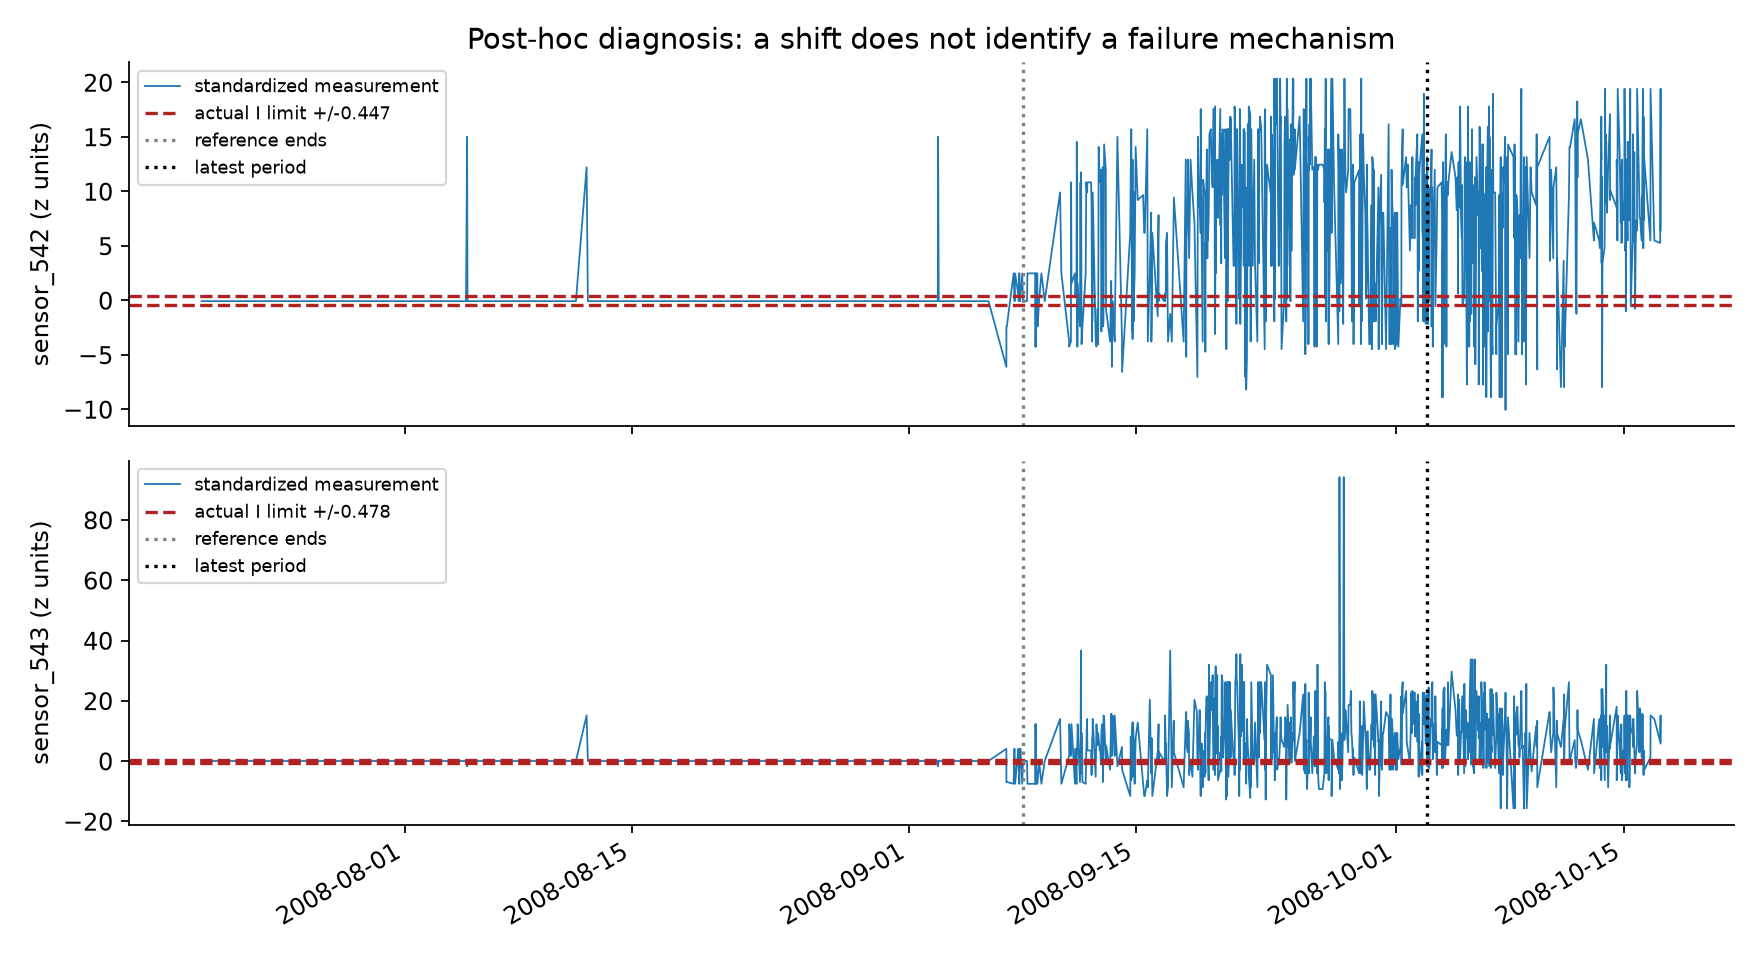

In [3]:
d = table('sensor_diagnostics')
display(d[d.feature.isin(['sensor_542','sensor_543'])])
display(Image(filename=str(OUT/'figures/alarm_diagnosis.png'), width=1000))

## Reference sensitivity
Variables are kept fixed while the reference population changes. All variants are reported; no later-label winner is promoted. Sensitivity variants start state at the evaluation boundary, whereas the main chart carries state from the end of reference fitting.

In [4]:
display(table('reference_sensitivity'))

,reference_policy,reference_rows,method,alert_rate,failure_recall,failure_capture,precision,false_positive_rate,alerts_per_100_runs,failure_capture_lift_over_random,pass_runs_between_false_alerts,alerts,failures_captured,false_alerts
0,early_pass,684,imr,0.353503,0.470588,0.470588,0.072072,0.346801,35.350318,1.331214,1.862745,111,8,103
1,early_pass,684,ewma,0.643312,0.764706,0.764706,0.064356,0.636364,64.331210,1.188701,0.537234,202,13,189
2,early_pass,684,cusum,0.974522,0.941176,0.941176,0.052288,0.976431,97.452229,0.965782,0.000000,306,16,290
3,early_all,751,imr,0.340764,0.411765,0.411765,0.065421,0.336700,34.076433,1.208356,1.949495,107,7,100
4,early_all,751,ewma,0.617834,0.764706,0.764706,0.067010,0.609428,61.783439,1.237720,0.605556,194,13,181
5,early_all,751,cusum,0.974522,0.941176,0.941176,0.052288,0.976431,97.452229,0.965782,0.000000,306,16,290
6,recent_pass,482,imr,0.388535,0.294118,0.294118,0.040984,0.393939,38.853503,0.756991,1.525862,122,5,117
7,recent_pass,482,ewma,0.372611,0.352941,0.352941,0.051282,0.373737,37.261146,0.947210,1.627273,117,6,111
8,recent_pass,482,cusum,0.757962,0.529412,0.529412,0.037815,0.771044,75.796178,0.698468,0.267544,238,9,229


## Known-change simulation (separate synthetic experiment)
Use stable Gaussian noise, a 1-sigma mean step and a gradual rise to 2 sigma. Repeated trials estimate pre-change false alarms and post-change detection. Undetected changes are retained as censored trials. No real fabrication lead time is inferred.

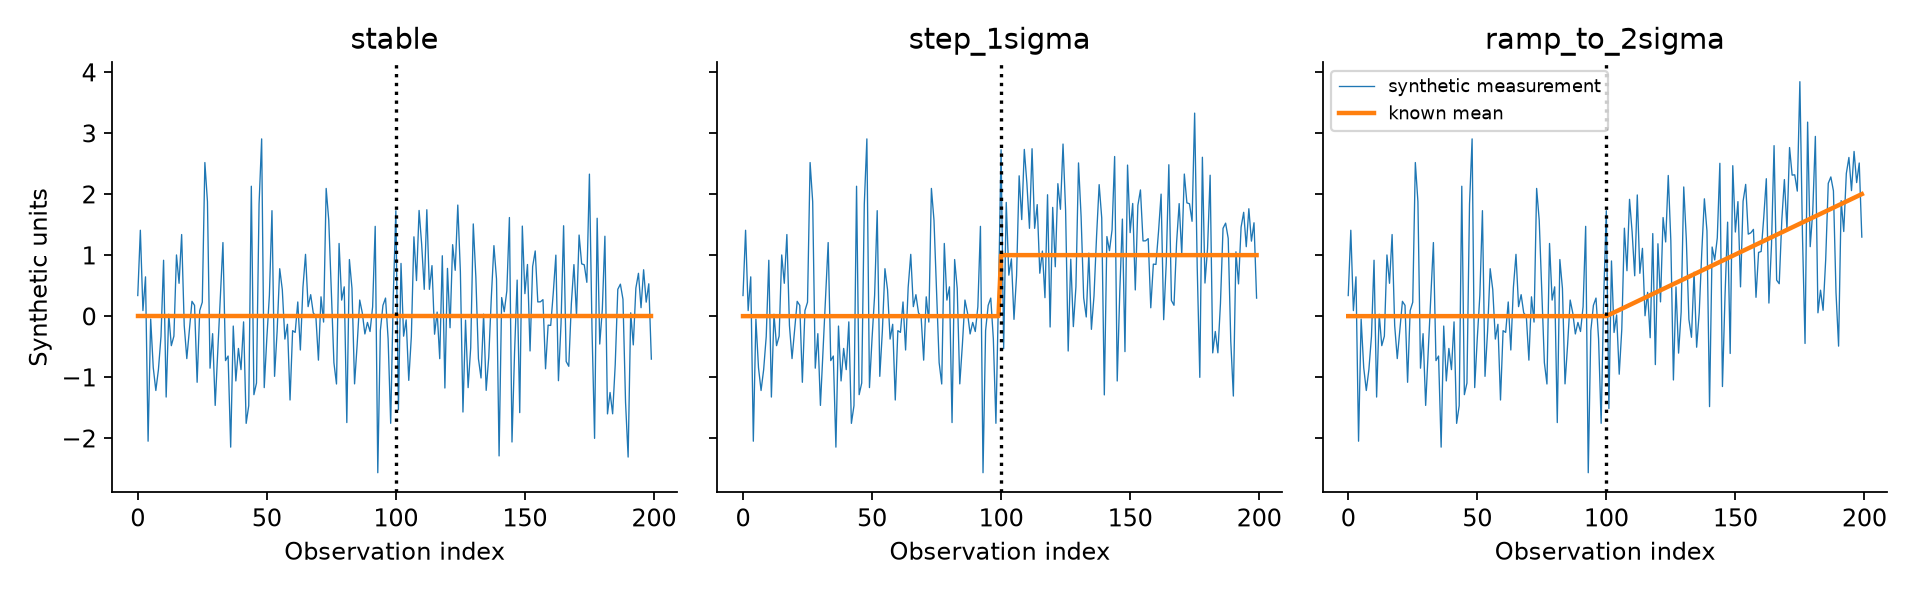

,scenario,method,trials,prechange_alert_fraction,prechange_probability_any_alert,postchange_alert_fraction,detection_probability,median_delay_among_detected,mean_restricted_delay
0,stable,imr,200,0.01270,0.645,0.01300,NaN,NaN,NaN
1,stable,ewma,200,0.00315,0.175,0.00415,NaN,NaN,NaN
2,stable,cusum,200,0.00860,0.220,0.01195,NaN,NaN,NaN
3,step_1sigma,imr,200,0.01270,0.645,0.03330,0.88,24.0,38.295
4,step_1sigma,ewma,200,0.00315,0.175,0.46275,1.00,8.0,11.240
5,step_1sigma,cusum,200,0.00860,0.220,0.89440,1.00,8.0,10.095
6,ramp_to_2sigma,imr,200,0.01270,0.645,0.05295,0.98,48.0,48.745
7,ramp_to_2sigma,ewma,200,0.00315,0.175,0.46365,1.00,39.0,38.500
8,ramp_to_2sigma,cusum,200,0.00860,0.220,0.59325,1.00,39.0,36.965


In [5]:
display(Image(filename=str(OUT/'figures/simulation.png'), width=1000))
display(table('simulation_summary'))
trials = table('simulation_trials')
assert trials.groupby(['scenario','method']).size().nunique() == 1

## Explanation boundaries
Q/SPE residual contributions explain PCA reconstruction error only. Classifier permutation importance is evaluated in an earlier validation block and is a noisy association diagnostic. Neither identifies a causal physical root cause.

In [6]:
display(table('earlier_validation_importance').head(10))
display(table('case_studies')[['run_id','case_type','q_residual_top3_only']])

,feature,mean_ap_decrease,std_ap_decrease
0,sensor_059,0.016668,0.000188
1,sensor_126,0.007177,0.000576
2,sensor_167,0.005213,0.003080
3,sensor_064,0.004699,0.006276
4,sensor_021,0.002755,0.001423
5,sensor_302,0.002039,0.007774
6,sensor_436,0.001839,0.001185
7,sensor_301,0.001432,0.003073
8,sensor_438,0.001425,0.000728
9,sensor_166,0.001392,0.004431


,run_id,case_type,q_residual_top3_only
0,1253,false_alert,sensor_472; sensor_455; sensor_183
1,1254,captured_failure,sensor_472; sensor_527; sensor_323
2,1302,missed_failure,sensor_472; sensor_527; sensor_187
